In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt 
import seaborn as sns 




In [5]:
df = pd.read_csv("EasyVisa.csv")
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
df.shape

(25480, 12)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


In [12]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [13]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [14]:
df.dtypes

case_id                   object
continent                 object
education_of_employee     object
has_job_experience        object
requires_job_training     object
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
prevailing_wage          float64
unit_of_wage              object
full_time_position        object
case_status               object
dtype: object

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [6]:
# Numéricas (enteros y decimales)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Texto o Categóricas
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [7]:

cat_cols

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [20]:
num_cols

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

In [23]:
from matplotlib.colors import Normalize
for col in cat_cols:
    print(df[col].value_counts(normalize=True)*100)
    print("------------")

case_id
EZYV25480    0.003925
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
               ...   
EZYV12       0.003925
EZYV13       0.003925
EZYV14       0.003925
EZYV15       0.003925
EZYV16       0.003925
Name: proportion, Length: 25480, dtype: float64
------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
------------
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.9034

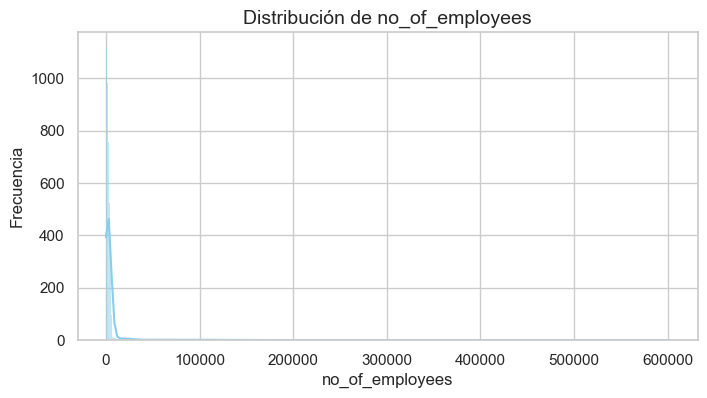

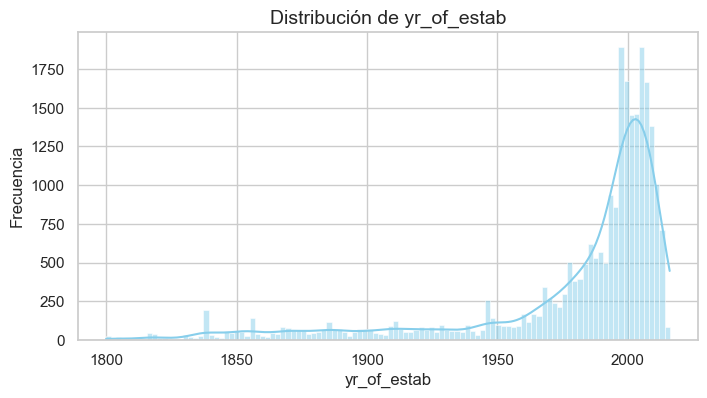

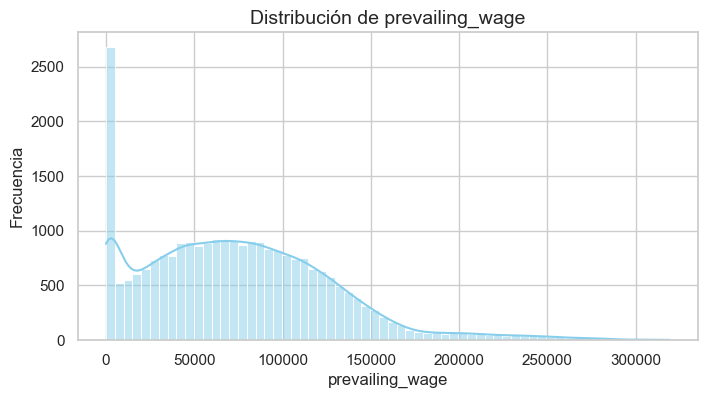

In [31]:
columnas_numericas = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True, color='skyblue')
    plt.title(f'Distribución de {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()


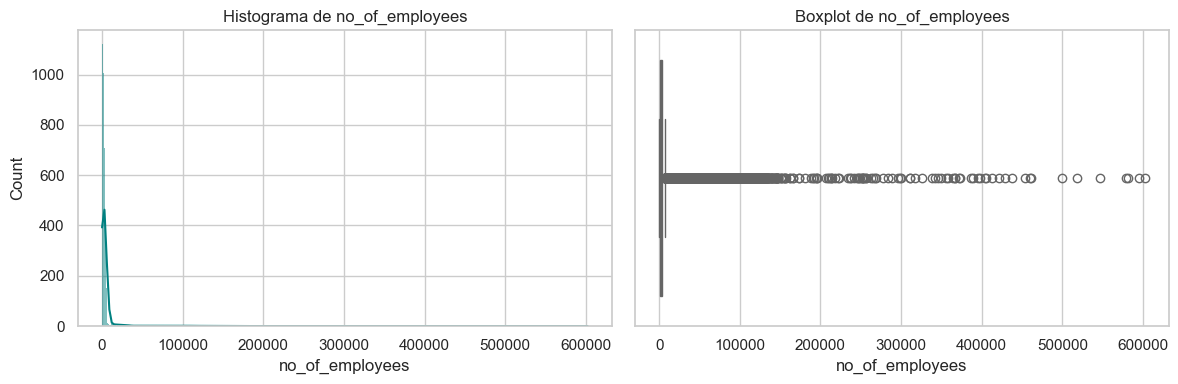

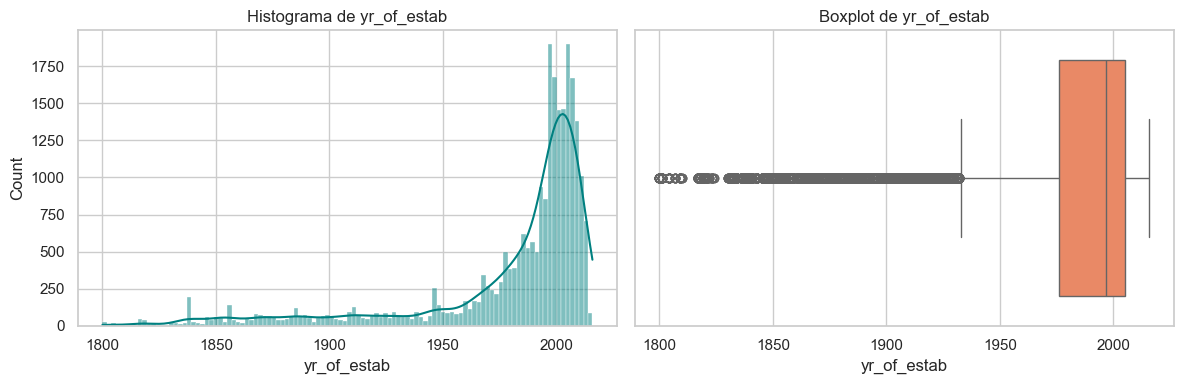

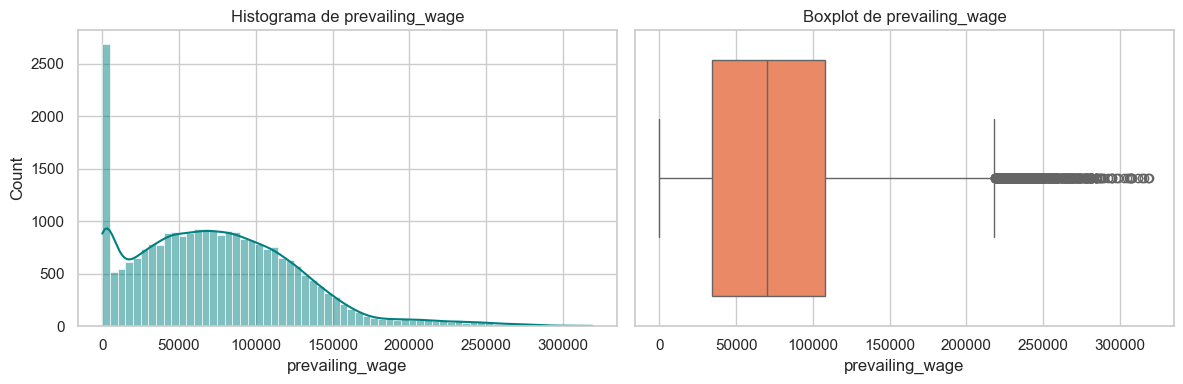

In [32]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma
    sns.histplot(df[col], kde=True, ax=axes[0], color='teal')
    axes[0].set_title(f'Histograma de {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='coral')
    axes[1].set_title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    # Asignamos hue=col y legend=False para evitar el warning
    sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
    plt.title(f'Análisis Univariado - {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Crear una tabla de contingencia (frecuencias cruzadas)
tabla_contingencia = pd.crosstab(df['education_of_employee'], df['case_status'])

# 2. Aplicar la prueba Chi2
chi2, p_valor, dof, esperados = chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("-> Existe una relación significativa entre la educación y el estatus de la visa.")
else:
    print("-> Las variables son independientes (no hay relación).")
